# Supplementary evaluation study

This notebook was added during repository restructuring. It is separate from the three original forecasting projects in the parent folder. Its saved outputs use a different protocol and must not be combined with their metrics. Read the [supplementary guide](../../docs/supplementary/README.md) first.


# 01 · Data, protocol and the persistence baseline

**Question.** Before comparing models: what do the data look like, how is a forecast evaluated,
and how hard is the baseline every model has to beat?

**This notebook**
1. loads each price series and reports data-quality facts (nothing is repaired or imputed);
2. describes returns using **only data before the final test period**; the test segment is not
   looked at until notebook 02;
3. states the evaluation protocol: chronological segments, forecast origins, horizons,
   refit schedule and the label-availability rule;
4. scores the two reference forecasts, persistence (`naive`) and trailing `drift`, on the
   validation segment.

**Targets** are *h*-step log returns `log(y[t+h] / y[t])` for *h* = 1, 5 and 20 **observations**
(trading sessions). A forecast origin `t` means row `t` is the last observation known.

> **Data.** Raw files are not redistributed. If `data/raw/vn30.csv` and `data/raw/bid.csv` are
> missing the notebook runs on a synthetic series and says so. Outputs saved in the committed
> notebook come from the real files described in [`docs/data.md`](../../docs/supplementary/data.md).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tsresearch.workspace import load_studies

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

studies = load_studies()
for s in studies:
    kind = "SYNTHETIC DEMO" if s.demo else "real data"
    print(f"{s.name:5s} [{kind}]  {len(s.dataset)} rows  {s.dataset.dates[0].date()} -> "
          f"{s.dataset.dates[-1].date()}  sha256={s.dataset.sha256[:12]}...")
if any(s.demo for s in studies):
    print("\nDEMO MODE: real files not found in data/raw/, so synthetic data is used. "
          "Numbers differ from the committed real-data run.")

VN30  [real data]  4426 rows  2009-01-05 -> 2026-09-28  sha256=1b91f9f2d89a...
BID   [real data]  3153 rows  2014-01-27 -> 2026-09-24  sha256=918ad0197245...


## 1. Data quality

Facts about each file. Rows are kept as supplied; flagged rows are masked only inside OHLC-derived features.

In [2]:
from tsresearch.data import quality_report

quality = pd.DataFrame([quality_report(s.dataset) for s in studies]).set_index("name").T
display(quality)
for s in studies:
    s.save_table(pd.DataFrame([quality_report(s.dataset)]), "01_data_quality")

name,VN30,BID
source_file,vn30.csv,bid.csv
sha256,1b91f9f2d89a35e15478eac85ff6de6d227458b427ff0e...,918ad01972453e616a6042da5a897c7137cf943105bb62...
rows,4426,3153
first_date,2009-01-05,2014-01-27
last_date,2026-09-28,2026-09-24
rows_with_ohlc,4426,3153
ohlc_inconsistent_rows,1,1
rows_with_volume,3567,3153
weekend_dated_rows,4,0
gaps_over_5_calendar_days,26,20


## 2. The series before the test period

Dashed lines mark the start of the validation segment. The test period is deliberately not drawn.

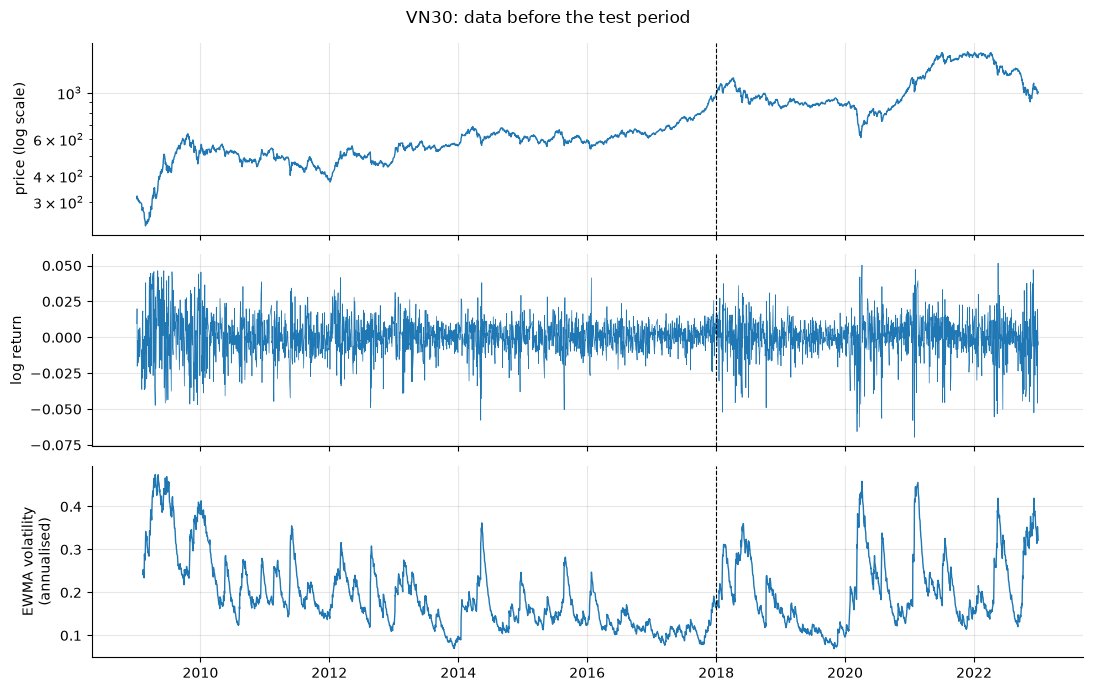

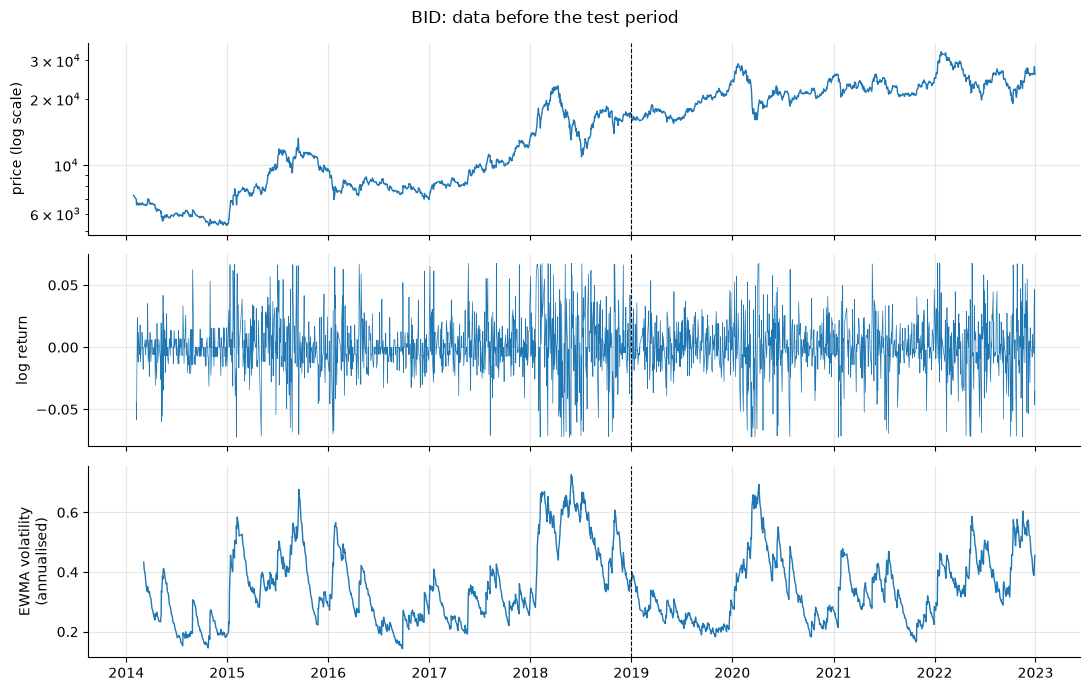

In [3]:
from tsresearch.features import ewma_volatility

pre_test = {}
for s in studies:
    frame = s.dataset.frame
    pre = frame[frame["ds"] < pd.Timestamp(s.protocol.test_start)].reset_index(drop=True)
    pre_test[s.name] = pre
    ret = np.log(pre["y"]).diff()
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 7))
    axes[0].semilogy(pre["ds"], pre["y"], lw=1)
    axes[0].set_ylabel("price (log scale)")
    axes[1].plot(pre["ds"], ret, lw=0.5)
    axes[1].set_ylabel("log return")
    axes[2].plot(pre["ds"], ewma_volatility(ret) * np.sqrt(252), lw=1)
    axes[2].set_ylabel("EWMA volatility\n(annualised)")
    for ax in axes:
        ax.axvline(pd.Timestamp(s.protocol.validation_start), color="k", ls="--", lw=0.8)
    fig.suptitle(f"{s.name}: data before the test period")
    fig.tight_layout()
    s.save_figure(fig, "01_series_overview")
    plt.show()

## 3. Return characteristics by period

Daily log returns are close to uncorrelated while their magnitudes are not (volatility clustering), and the level of volatility differs across periods. Both facts shape the evaluation and the interval methods in notebook 03.

In [4]:
def describe(returns):
    r = returns.dropna()
    return pd.Series({
        "n": len(r), "mean_%": 100 * r.mean(), "std_%": 100 * r.std(),
        "skew": r.skew(), "excess_kurtosis": r.kurt(),
        "autocorr_lag1": r.autocorr(1), "autocorr_abs_lag1": r.abs().autocorr(1)})


rows = {}
for s in studies:
    pre = pre_test[s.name]
    ret = np.log(pre["y"]).diff()
    split = pd.Timestamp(s.protocol.validation_start)
    rows[(s.name, "train (before validation)")] = describe(ret[pre["ds"] < split])
    rows[(s.name, "validation period")] = describe(ret[pre["ds"] >= split])
summary = pd.DataFrame(rows).T
display(summary.round(4))
for s in studies:
    s.save_table(summary.loc[s.name].reset_index(names="period"), "01_return_summary")

n  mean_%   std_%    skew  excess_kurtosis  autocorr_lag1  autocorr_abs_lag1
VN30 train (before validation)  2243.0  0.0509  1.2939 -0.1588           2.0357         0.1587             0.3028
     validation period          1250.0  0.0024  1.4103 -0.8410           3.4109         0.0340             0.2296
BID  train (before validation)  1226.0  0.0708  2.3537  0.1170           1.7121         0.0319             0.2675
     validation period          1001.0  0.0399  2.2798 -0.3572           1.7011        -0.0076             0.2061

## 4. Evaluation protocol

| Element | Rule |
| --- | --- |
| Information set | Row `t` and everything before it. Features are rolling or lagged quantities. |
| Target | `log(y[t+h] / y[t])`, *h* = 1, 5, 20 observations; one **direct** forecast per horizon. |
| Segments | `train` (fit only) → `validation` (choose settings) → `test` (frozen choices, run once). Dates are fixed in [`configs/protocol.json`](../../configs/protocol.json). |
| Embargo | Validation origins stop `max(h)` rows before the test starts, so no validation target overlaps the test period. |
| Origins | Every observation inside a segment (step 1), all horizons on identical origins. |
| Refit | Every 20 origins, expanding window. |
| Label availability | A fit at origin `o` uses training rows `t` only if `t + max(h) <= o`. |
| Metrics | RMSE and MAE of the return forecast, **relative to persistence**, MASE, directional accuracy, and price-level MAPE (secondary). |
| Comparison | Diebold-Mariano test with HAC variance, block-bootstrap interval, Holm correction. |

The label-availability rule, the invariance of forecasts to anything after the origin, and the
validation/test embargo are unit-tested in [`tests/`](../../tests).

In [5]:
from tsresearch.protocol import segment_table

for s in studies:
    print(f"{s.name}: horizons={s.protocol.horizons}, refit every {s.protocol.refit_every} origins, "
          f"min_train={s.protocol.min_train}, window={'expanding' if s.protocol.train_window is None else s.protocol.train_window}")
    table = segment_table(s.dataset.dates, s.protocol)
    display(table)
    s.save_table(table, "01_segments")

VN30: horizons=(1, 5, 20), refit every 20 origins, min_train=750, window=expanding


,segment,first_origin,last_origin,origins
0,train (fit only),2009-04-07,2017-12-29,2184
1,validation,2018-01-02,2022-12-02,1230
2,test,2023-01-03,2026-08-28,912


BID: horizons=(1, 5, 20), refit every 20 origins, min_train=750, window=expanding


,segment,first_origin,last_origin,origins
0,train (fit only),2014-05-06,2018-12-28,1167
1,validation,2019-01-02,2022-12-02,981
2,test,2023-01-03,2026-08-21,905


## 5. Reference forecasts on the validation segment

* `naive`: persistence, i.e. zero expected log return.
* `drift`: trailing 252-row mean return times *h*.

`rel_rmse` and `mase` below 1 mean *better than persistence*; direction accuracy is undefined for persistence because it never calls a direction.

In [6]:
from tsresearch.backtest import run_specs
from tsresearch.metrics import (diebold_mariano, loss_differential, mase_scale,
                                point_metrics)

BASELINES = [{"family": "naive"}, {"family": "drift"}]
baseline = {}
for s in studies:
    validation = run_specs(s.dataset, BASELINES, s.protocol, "validation", cache_dir=s.cache_dir)
    table = point_metrics(validation, mase_scale(s.dataset, s.protocol))
    baseline[s.name] = validation
    print(f"{s.name}: {table['n_origins'].iloc[0]} validation origins")
    display(table.drop(columns="rel_mae").round(4))
    s.save_table(table, "01_baselines_validation")

VN30: 1230 validation origins


,model,horizon,n_origins,rmse,mae,rel_rmse,direction_acc,price_mape_pct,mase
0,naive,1,1230,0.0140,0.0096,1.0000,NaN,0.9576,1.0148
1,naive,5,1230,0.0331,0.0242,1.0000,NaN,2.4249,1.0163
2,naive,20,1230,0.0682,0.0503,1.0000,NaN,5.0920,0.9823
3,drift,1,1230,0.0140,0.0095,1.0027,0.5106,0.9567,1.0133
4,drift,5,1230,0.0335,0.0243,1.0119,0.5057,2.4387,1.0202
5,drift,20,1230,0.0720,0.0530,1.0553,0.4951,5.3939,1.0343


BID: 981 validation origins

,model,horizon,n_origins,rmse,mae,rel_rmse,direction_acc,price_mape_pct,mase
0,naive,1,981,0.0228,0.0162,1.0000,NaN,1.6245,0.9950
1,naive,5,981,0.0503,0.0369,1.0000,NaN,3.6994,0.9635
2,naive,20,981,0.1060,0.0797,1.0000,NaN,8.0218,0.9515
3,drift,1,981,0.0228,0.0163,1.0019,0.4762,1.6326,0.9995
4,drift,5,981,0.0508,0.0372,1.0095,0.4958,3.7308,0.9695
5,drift,20,981,0.1101,0.0816,1.0391,0.4985,8.3019,0.9736


Is the drift forecast distinguishable from persistence? Diebold-Mariano test on squared error, negative statistic = drift better.

In [7]:
rows = []
for s in studies:
    for h in s.protocol.horizons:
        d = loss_differential(baseline[s.name], "drift", "naive", h)
        rows.append({"dataset": s.name, "horizon": h, **diebold_mariano(d, h)})
dm = pd.DataFrame(rows)
display(dm.round(4))

,dataset,horizon,mean_diff,dm_stat,p_value
0,VN30,1,0.0000,1.0061,0.3145
1,VN30,5,0.0000,1.1526,0.2493
2,VN30,20,0.0005,1.6236,0.1047
3,BID,1,0.0000,1.7433,0.0816
4,BID,5,0.0000,1.9603,0.0502
5,BID,20,0.0009,1.6250,0.1045


### Findings (committed run: VN30 and BID, snapshots listed in [`docs/data.md`](../../docs/supplementary/data.md))

* **Returns are nearly unpredictable from their own past; their size is not.** Lag-1
  autocorrelation of daily returns in the validation period is 0.034 (VN30) and -0.008 (BID),
  whereas for absolute returns it is 0.23 and 0.21 (volatility clustering). For VN30 the return
  autocorrelation was 0.16 in the earlier training years, so even that weak linear structure
  has faded.
* **Volatility level shifts between periods** (VN30 daily standard deviation 1.29% in the
  training years vs 1.41% in the validation period; skewness -0.16 vs -0.84). Anything
  calibrated on one period must be checked on another (notebook 03).
* **Persistence is a hard baseline and the trailing drift does not improve on it.** On the
  validation segment the drift forecast has RMSE ratio above 1 at every horizon on both
  datasets (1.003-1.055 for VN30, 1.002-1.039 for BID). A one-session persistence forecast
  already has a price-level MAPE of 0.96% (VN30) and 1.62% (BID), so low MAPE alone says
  nothing about skill.
* **Data caveats** are in the quality table and [`docs/data.md`](../../docs/supplementary/data.md): VN30 contains
  four weekend-dated rows (all after the validation period), and one row per file has
  inconsistent OHLC values.

Nothing from the test segment was used or displayed in this notebook.